In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

In [32]:
df = pd.read_csv("../data/Processed_HR_Employee_Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [33]:
# Label Encoding for Attrition column
label = LabelEncoder()
df['Attrition'] = label.fit_transform(df['Attrition'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   object
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   object
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   object
 12  JobLevel                  1470 non-null   object
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [34]:
# One-Hot Encoding for Categorical Variables
dummy_col = [column for column in df.drop('Attrition', axis=1).columns if df[column].nunique() < 20]
data = pd.get_dummies(df, columns=dummy_col, drop_first=True, dtype='uint8')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Columns: 136 entries, Age to YearsWithCurrManager_17
dtypes: int64(9), uint8(127)
memory usage: 285.8 KB


In [35]:
print("Before removing duplicates: ", data.shape)

data = data.T.drop_duplicates().T
data.drop_duplicates(inplace=True)

print("After removing duplicates: ", data.shape)

Before removing duplicates:  (1470, 136)
After removing duplicates:  (1470, 136)


<Axes: >

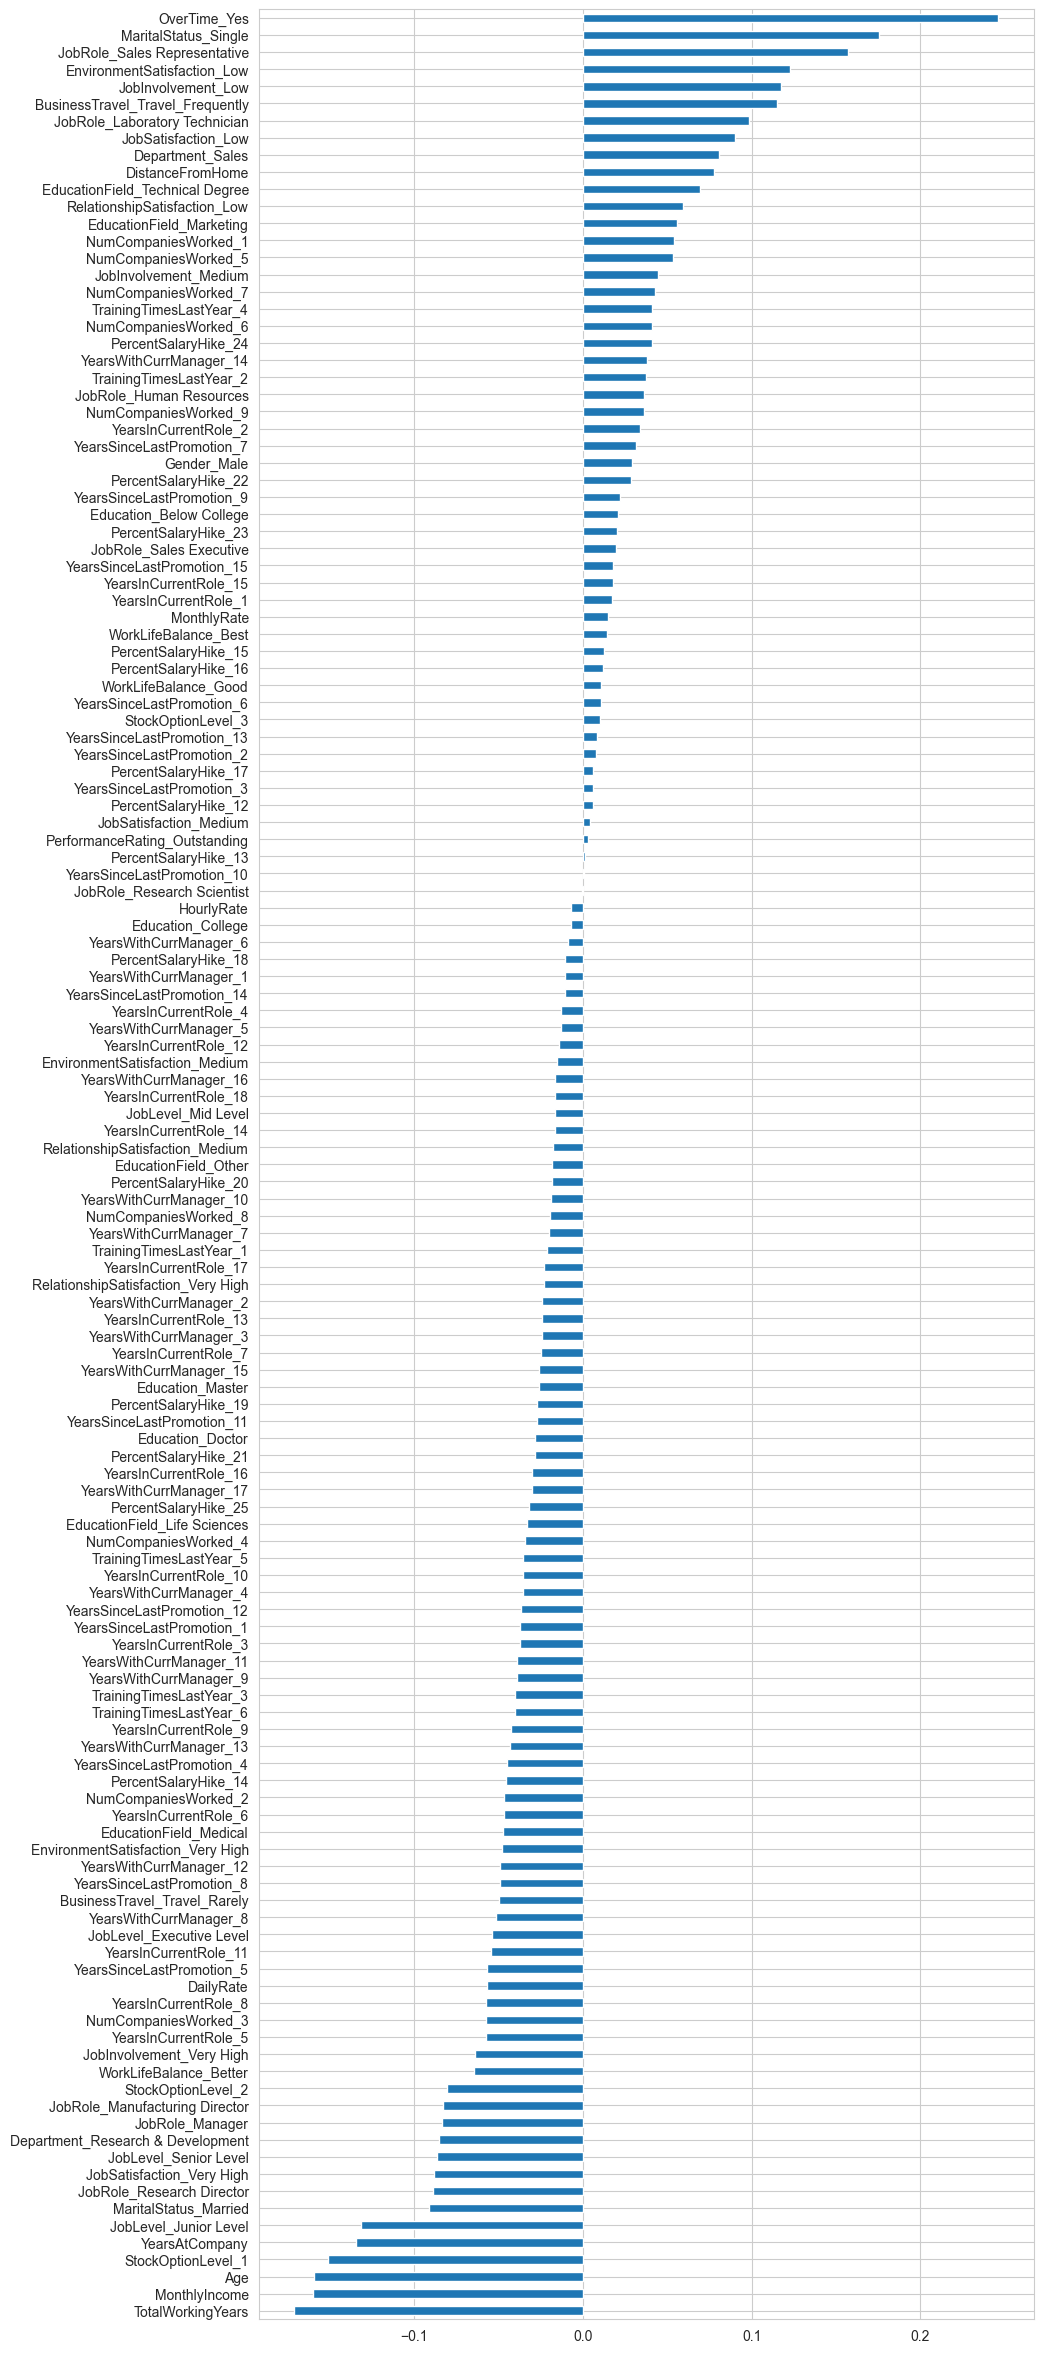

In [36]:
data.drop('Attrition', axis=1).corrwith(data.Attrition).sort_values().plot(kind='barh', figsize=(10, 30))

In [37]:
X = data.drop('Attrition', axis=1)
y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (1176, 135)
Testing shape: (294, 135)


In [38]:
# Setting up pipelines for different models
pipelines = {
  'Logistic Regression': ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
  ]),
    
  'Random Forest': ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
  ]),
    
  'XGBoost': ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
  ]),
    
  'SVM': ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
  ])
}

In [39]:
# Execute 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_list = []
detailed_scores = {name: [] for name in pipelines.keys()}

print("Running 5-Fold Stratified Cross-Validation...")
print("-" * 60)
print(f"{'Model':<20} | {'Mean F1':<10} | {'Std Dev':<10} | {'Mean AUC':<10}")
print("-" * 60)

for name, pipeline in pipelines.items():
    # We capture both F1 (for minority class accuracy) and ROC_AUC (for overall ranking)
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=['f1', 'roc_auc'])
    
    # Store raw scores for plotting
    detailed_scores[name] = cv_results['test_f1']
    
    # Calculate Summary Stats
    mean_f1 = cv_results['test_f1'].mean()
    std_f1 = cv_results['test_f1'].std()
    mean_auc = cv_results['test_roc_auc'].mean()
    
    print(f"{name:<20} | {mean_f1:.4f}     | {std_f1:.4f}     | {mean_auc:.4f}")
    
    results_list.append({
        'Model': name,
        'Mean_F1': mean_f1,
        'Std_F1': std_f1,
        'Mean_AUC': mean_auc
    })
results_df = pd.DataFrame(results_list).sort_values(by='Mean_F1', ascending=False)

Running 5-Fold Stratified Cross-Validation...
------------------------------------------------------------
Model                | Mean F1    | Std Dev    | Mean AUC  
------------------------------------------------------------
Logistic Regression  | 0.5324     | 0.0406     | 0.8093
Random Forest        | 0.3232     | 0.1064     | 0.7578
XGBoost              | 0.4520     | 0.1145     | 0.7814
SVM                  | 0.4617     | 0.0656     | 0.8091


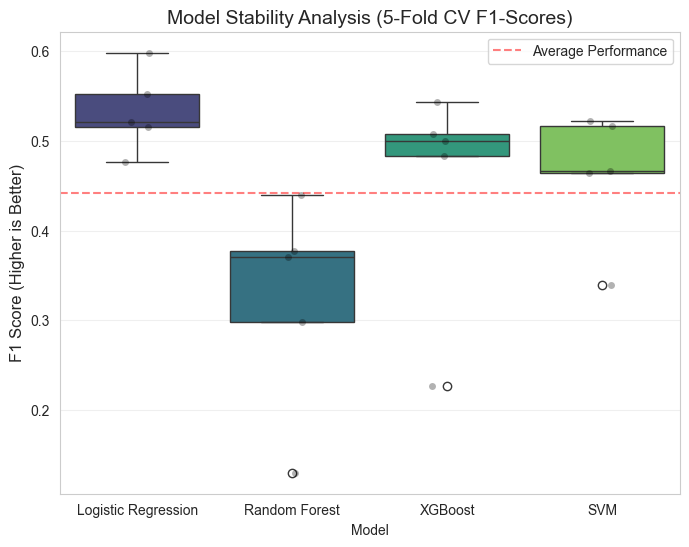

In [40]:
plot_data = pd.DataFrame(detailed_scores).melt(var_name='Model', value_name='F1 Score')
plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_data, x='Model', y='F1 Score', palette='viridis')
sns.stripplot(data=plot_data, x='Model', y='F1 Score', color='black', alpha=0.3, jitter=True) # Shows actual fold dots

plt.title('Model Stability Analysis (5-Fold CV F1-Scores)', fontsize=14)
plt.ylabel('F1 Score (Higher is Better)', fontsize=12)
plt.axhline(results_df['Mean_F1'].mean(), color='red', linestyle='--', alpha=0.5, label='Average Performance')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [41]:
top_2 = results_df.head(2)
winner_1 = top_2.iloc[0]
winner_2 = top_2.iloc[1]

print("\n" + "="*60)
print(">>> PHASE 1 CONCLUSION: TOP 2 MODELS SELECTED")
print("="*60)
print(f"1. {winner_1['Model']} (Leader)")
print(f"   - Reasoning: Highest F1-Score ({winner_1['Mean_F1']:.2f}). This model is best at identifying leavers.")
print(f"   - Stability: +/- {winner_1['Std_F1']:.2f} (Standard Deviation)")

print(f"\n2. {winner_2['Model']} (Challenger)")
print(f"   - Reasoning: Second best F1-Score ({winner_2['Mean_F1']:.2f}).")
print(f"   - Ensemble Potential: Combining this with {winner_1['Model']} may smooth out errors.")

print(f"\nAction: These two models will be used to build the Voting Ensemble.")


>>> PHASE 1 CONCLUSION: TOP 2 MODELS SELECTED
1. Logistic Regression (Leader)
   - Reasoning: Highest F1-Score (0.53). This model is best at identifying leavers.
   - Stability: +/- 0.04 (Standard Deviation)

2. SVM (Challenger)
   - Reasoning: Second best F1-Score (0.46).
   - Ensemble Potential: Combining this with Logistic Regression may smooth out errors.

Action: These two models will be used to build the Voting Ensemble.


Final Evaluation on Hold-out Test Set (X_test)...
----------------------------------------------------------------------
Model                | F1       | AUC      | Recall   | Precision
----------------------------------------------------------------------
Logistic Regression  | 0.5167   | 0.8188   | 0.6596   | 0.4247
SVM                  | 0.3836   | 0.8030   | 0.2979   | 0.5385
Voting Ensemble      | 0.5106   | 0.8207   | 0.5106   | 0.5106


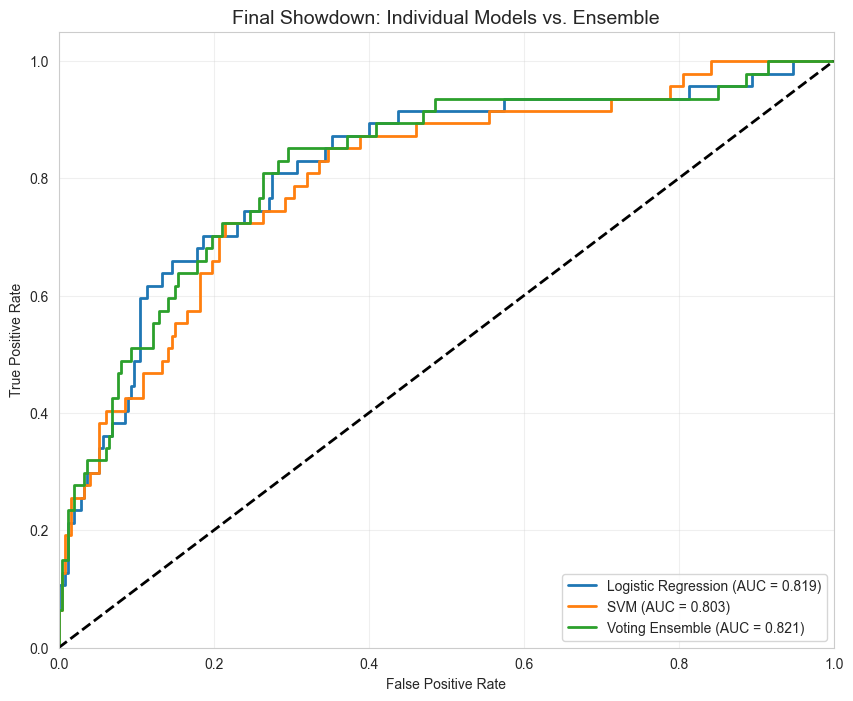

                 Model    Metric     Score
0  Logistic Regression  F1 Score  0.516667
1  Logistic Regression   ROC-AUC  0.818847
2  Logistic Regression    Recall  0.659574
3                  SVM  F1 Score  0.383562
4                  SVM   ROC-AUC  0.802998
5                  SVM    Recall  0.297872
6      Voting Ensemble  F1 Score  0.510638
7      Voting Ensemble   ROC-AUC  0.820656
8      Voting Ensemble    Recall  0.510638


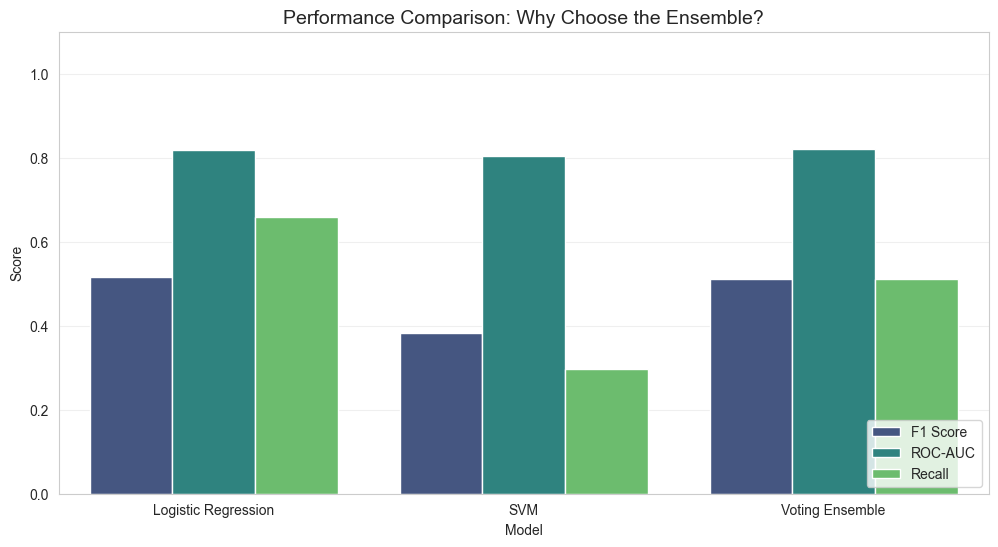

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score, roc_curve, auc

# --- 1. SETUP THE ENSEMBLE ---
# identifying the top 2 models (Manually or from previous code)
# Let's assume Logistic Regression and Random Forest were the winners
model_1_name = 'Logistic Regression'
model_2_name = 'SVM'

# Create the Ensemble using the pipelines we already defined
# 'voting=soft' is CRITICAL. It averages probabilities, not just yes/no votes.
ensemble_model = VotingClassifier(
    estimators=[
        (model_1_name, pipelines[model_1_name]),
        (model_2_name, pipelines[model_2_name])
    ],
    voting='soft'
)

# List of all final contenders
final_contenders = {
    model_1_name: pipelines[model_1_name],
    model_2_name: pipelines[model_2_name],
    'Voting Ensemble': ensemble_model
}

# --- 2. TRAIN & EVALUATE ON TEST SET ---
results_data = []
plt.figure(figsize=(10, 8))

print("Final Evaluation on Hold-out Test Set (X_test)...")
print("-" * 70)
print(f"{'Model':<20} | {'F1':<8} | {'AUC':<8} | {'Recall':<8} | {'Precision':<8}")
print("-" * 70)

for name, model in final_contenders.items():
    # A. Train on FULL Training Data
    model.fit(X_train, y_train)
    
    # B. Predict on Test Data
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probability of 'Yes'
    
    # C. Calculate Metrics
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    print(f"{name:<20} | {f1:.4f}   | {roc:.4f}   | {rec:.4f}   | {prec:.4f}")
    
    # Store for Bar Chart
    results_data.append({'Model': name, 'Metric': 'F1 Score', 'Score': f1})
    results_data.append({'Model': name, 'Metric': 'ROC-AUC', 'Score': roc})
    results_data.append({'Model': name, 'Metric': 'Recall', 'Score': rec})
    
    # D. Add to ROC Plot
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc:.3f})')

# --- 3. PLOT 1: ROC CURVE COMPARISON ---
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Showdown: Individual Models vs. Ensemble', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# --- 4. PLOT 2: METRIC COMPARISON BAR CHART ---
results_df = pd.DataFrame(results_data)


plt.figure(figsize=(12, 6))

sns.barplot(data=results_df, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Performance Comparison: Why Choose the Ensemble?', fontsize=14)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()